In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn import metrics

from mlxtend.plotting import plot_confusion_matrix

In [27]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [28]:
df = df[df['Species'].isin(['Iris-setosa','Iris-versicolor'])]

In [29]:
df['Y'] = df['Species'].map({
    'Iris-setosa':0,
    'Iris-versicolor':1
})

In [30]:
X = df[['SepalLengthCm','SepalWidthCm']].values
Y = df['Y'].values

In [31]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [32]:
def evaluate_model(model, X, Y):

    kf = KFold(n_splits=5, shuffle=True, random_state=2)

    train_acc_scores = []
    test_acc_scores = []

    for fold,(train_index,test_index) in enumerate(kf.split(X),1):

        X_train = X[train_index]
        X_test = X[test_index]

        Y_train = Y[train_index]
        Y_test = Y[test_index]

        # Train model
        model.fit(X_train,Y_train)

        # Learned parameters
        w1,w2 = model.coef_[0]
        b = model.intercept_[0]

        print("\nFold:",fold)
        print("w1 =",w1)
        print("w2 =",w2)
        print("b =",b)

        # Predictions
        Y_testPred = model.predict(X_test)
        Y_trainPred = model.predict(X_train)

        # Accuracy
        test_acc = metrics.accuracy_score(Y_test,Y_testPred)
        train_acc = metrics.accuracy_score(Y_train,Y_trainPred)

        print("Train Accuracy:",train_acc)
        print("Test Accuracy:",test_acc)

        train_acc_scores.append(train_acc)
        test_acc_scores.append(test_acc)

        # Confusion Matrix
        cm = metrics.confusion_matrix(Y_test,Y_testPred)

        fig, ax = plot_confusion_matrix(conf_mat=cm)
        plt.title("Confusion Matrix")
        plt.show()

        # Precision Recall F1
        print(metrics.classification_report(Y_test,Y_testPred))

        # ROC Curve
        probs = model.predict_proba(X_test)[:,1]

        fpr,tpr,thresholds = metrics.roc_curve(Y_test,probs)

        auc = metrics.roc_auc_score(Y_test,probs)

        plt.plot(fpr,tpr)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.show()

        print("AUC =",auc)

    print("\nAverage Train Accuracy:",np.mean(train_acc_scores))
    print("Average Test Accuracy:",np.mean(test_acc_scores))

In [33]:
model = LogisticRegression()


Fold: 1
w1 = 2.5537038977370043
w2 = -2.085796517348057
b = 0.33455071203981934
Train Accuracy: 1.0
Test Accuracy: 1.0


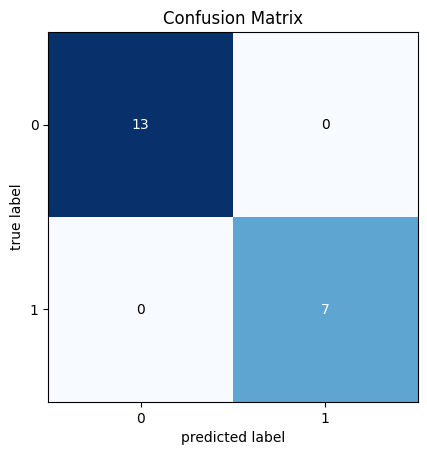

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



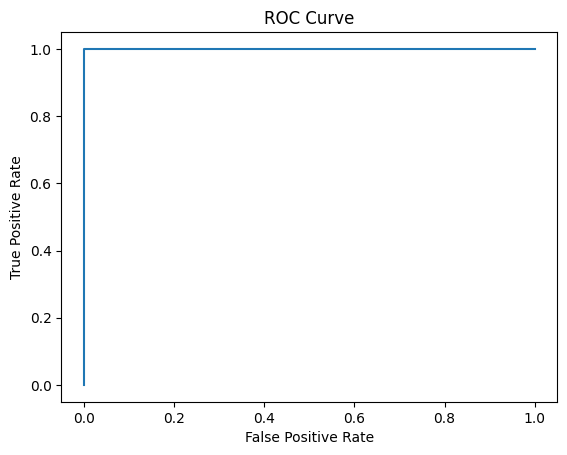

AUC = 1.0

Fold: 2
w1 = 2.594386627027585
w2 = -2.062033608912756
b = 0.36878550389509823
Train Accuracy: 1.0
Test Accuracy: 1.0


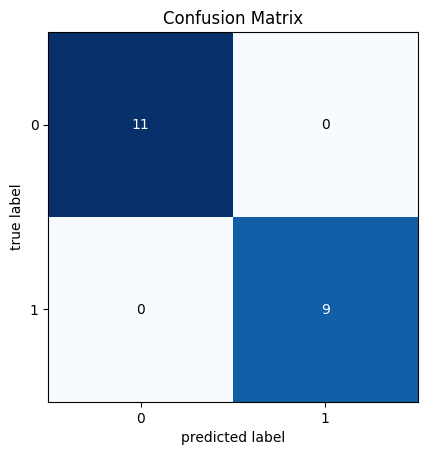

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



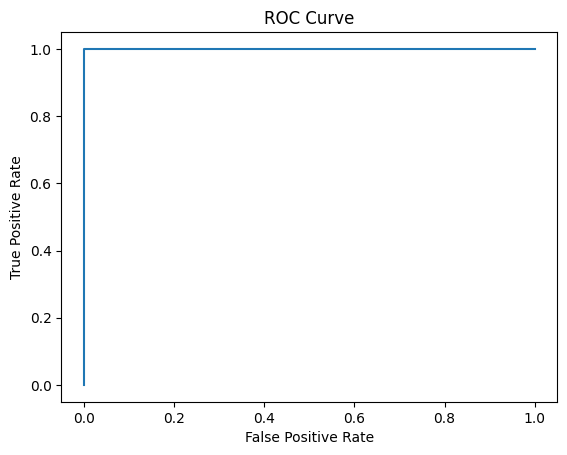

AUC = 1.0

Fold: 3
w1 = 2.391296416816615
w2 = -2.1957441524057453
b = 0.2080788320588585
Train Accuracy: 1.0
Test Accuracy: 0.95


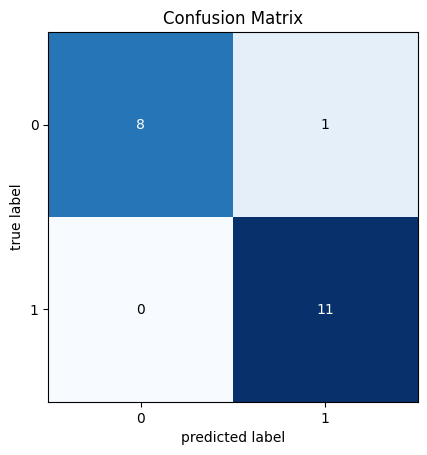

              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.92      1.00      0.96        11

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



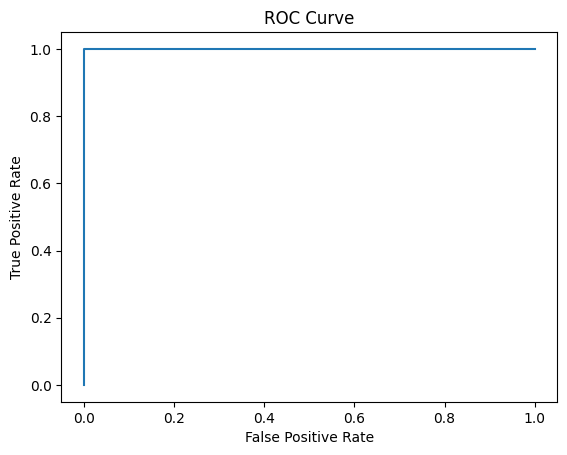

AUC = 1.0

Fold: 4
w1 = 2.5317288042644095
w2 = -2.1054007305118807
b = 0.03183099035543582
Train Accuracy: 1.0
Test Accuracy: 1.0


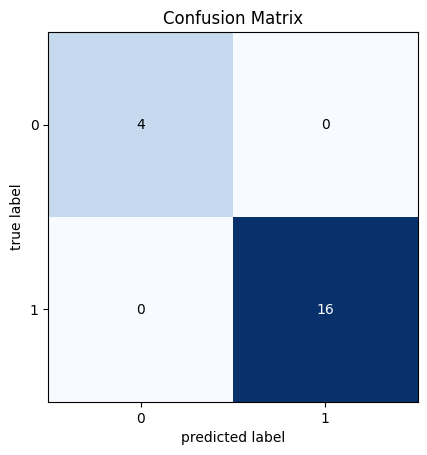

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00        16

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



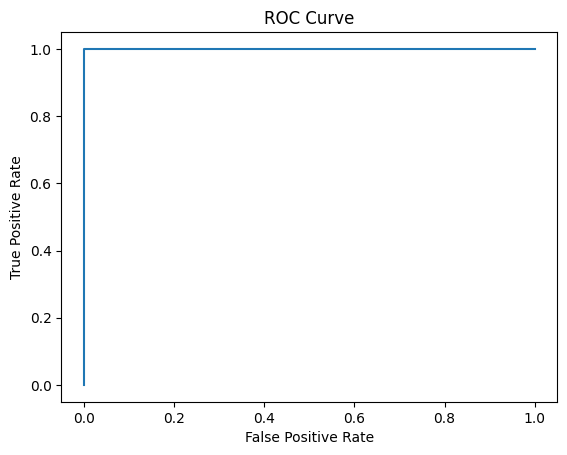

AUC = 1.0

Fold: 5
w1 = 2.543569592459072
w2 = -2.07441372069553
b = 0.35226698446868016
Train Accuracy: 1.0
Test Accuracy: 1.0


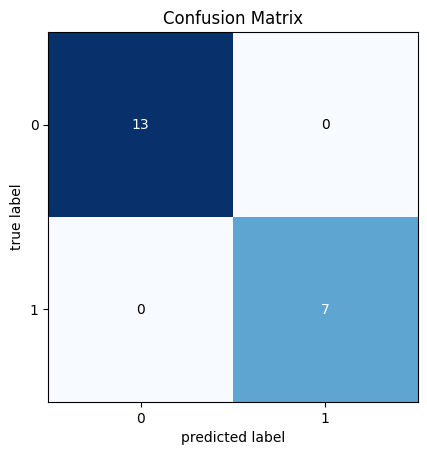

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



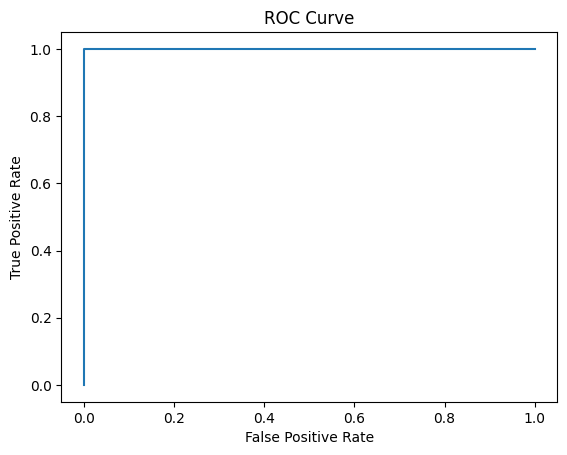

AUC = 1.0

Average Train Accuracy: 1.0
Average Test Accuracy: 0.99


In [34]:
evaluate_model(model, X, Y)